# Read the interop matrix

> See which array libraries RAPTOR officially supports, straight from the
> code — no table to trust blind.

**Time:** ~5 min · **Runs on:** CPU, no GPU needed, raptor alone (no
cupy/torch/warp required) · **You need:**
[Implement a protocol](03_implement_a_protocol)


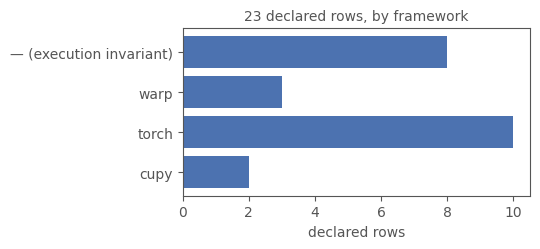

In [1]:
import sys; sys.path.insert(0, "../_shared")
from raptor.conformance import interop
from nb_diagrams import rows_by_framework_bar
rows_by_framework_bar(interop.ROWS)


## The code

`raptor.conformance.interop` declares two things, as plain tuples: which
frameworks are `CERTIFIED` today, and which are `ROADMAP` — declared, not
yet built:


In [2]:
from raptor.conformance import interop

print("certified:", interop.CERTIFIED)
print("roadmap  :", interop.ROADMAP)


certified: ('numpy', 'cupy', 'torch', 'warp')
roadmap  : ('jax', 'tensorflow')


Four certified frameworks today, two more on the roadmap — reading this costs nothing, with none of them installed.


Check which of the certified ones this environment actually has, the plain
way — no test framework needed, just whether each one imports:


In [3]:
import importlib.util

for fw in interop.CERTIFIED:
    found = importlib.util.find_spec(fw) is not None
    print(f"{fw:<10} {'found' if found else 'missing'}")


numpy      found
cupy       found
torch      found
warp       found


raptor itself needs none of these — this cell just reports what else happens to be installed here.


The same idea for `ROADMAP`: `jax` and `tensorflow` are declared absent
today. `roadmap_framework` checks both directions — declared-absent AND
actually-absent must agree, or it is a failure, not a quiet pass:


In [4]:
for fw in interop.ROADMAP:
    try:
        interop.roadmap_framework(fw)
        print(f"{fw}: absent, as declared")
    except AssertionError as exc:
        print(f"{fw}: unexpectedly installed in this environment -- {exc}")


jax: unexpectedly installed in this environment -- declared ROADMAP (absent-by-declaration) but INSTALLED — certify it or remove it from the env
tensorflow: absent, as declared


This page's own build machine happens to have `jax` installed for unrelated reasons — the line above says so honestly instead of hiding it; that is the check working, not the family's claim breaking.


Finally, look up one row directly in `ROWS` — the full declaration every
claim on the matrix page cites:


In [5]:
decl = interop.ROWS["T-IN-CUDA-ALIAS"]
print(f"T-IN-CUDA-ALIAS -> framework={decl.framework} owner={decl.owner_repo} kind={decl.kind}")


T-IN-CUDA-ALIAS -> framework=torch owner=eagle kind=ALIAS


`.framework`/`.owner_repo`/`.kind` are the three fields every declared row
carries. `kind` is how data crosses between the two sides — **`ALIAS`**
(seen above) means the same memory, no copy; the matrix page defines the
other four kinds (`COPY`, `STREAM`, `ENV`, `INVARIANCE`) in full.

## What just happened

- Reading `CERTIFIED`/`ROADMAP`/`ROWS` costs nothing: no certified framework
  needs to be installed just to read the declaration.
- Checking whether a framework is actually present only needs
  `importlib.util.find_spec` — the same plain check `interop` uses
  internally, no extra install required.
- `ROWS` names, for every crossing the family certifies, which repository's
  test suite proves it and how data crosses (`ALIAS`, `COPY`, `STREAM`,
  `ENV` or `INVARIANCE`).

## Try this

Look up a row you have not seen yet, e.g.
`interop.ROWS["T-DEVICE-FAILLOUD"]`, and read its `.framework`/`.owner_repo`/
`.kind` straight from the object instead of this page.

## Next

[Interoperability](/content/interop_protocols) is the full, human-readable
matrix — every row, what it certifies, and the ALIAS/COPY transfer laws
every crossing on this page obeys. Want to add a crossing of your own? See
[Contributing a certification row](/content/devguide/contributing_a_certification_row)
for the two-repository process and the hygiene scanners its gate runs.
